Window Size: 17
Horizon: 2
Hidden Size: 14
Using file: /kaggle/input/datasets/kandij/electric-production/Electric_Production.csv
Stock dataset not found — using synthetic data instead

===== Running on Electricity =====
Epoch 0, Loss: 0.8122
Epoch 10, Loss: 0.3352
Epoch 20, Loss: 0.2884
Epoch 30, Loss: 0.2713
Epoch 40, Loss: 0.2560


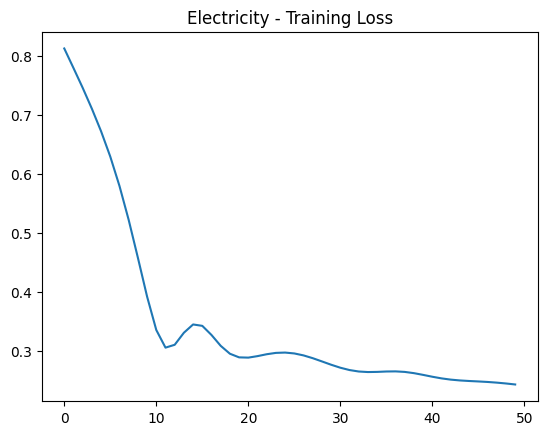

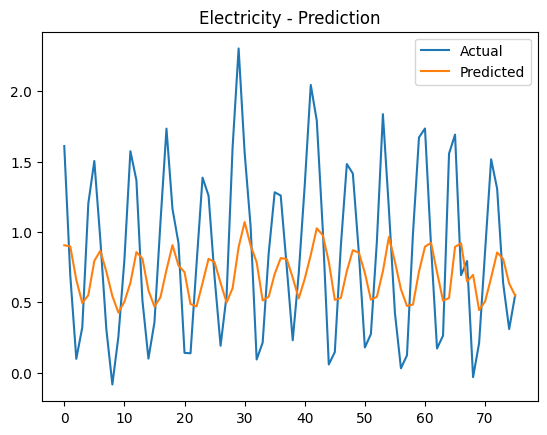

Electricity Results:
MSE: 0.3382882
MAE: 0.4865439832210541
RMSE: 0.58162546

===== Running on Stock =====
Epoch 0, Loss: 1.2560
Epoch 10, Loss: 0.5750
Epoch 20, Loss: 0.1652
Epoch 30, Loss: 0.0254
Epoch 40, Loss: 0.0181


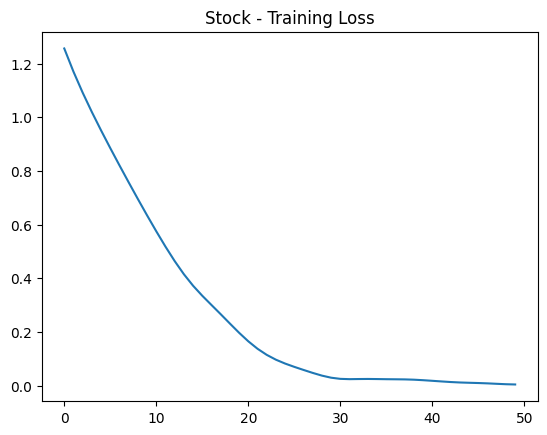

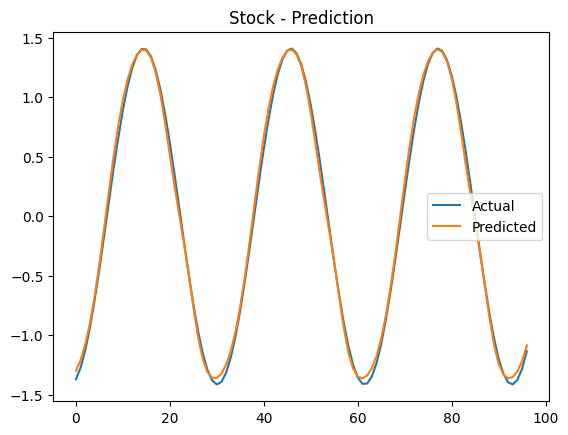

Stock Results:
MSE: 0.0039878003
MAE: 0.05322679132223129
RMSE: 0.063149035


In [1]:
# =========================================
# 📦 IMPORTS
# =========================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import os

# =========================================
# 🔢 PARAMETERS (ROLL NO BASED)
# =========================================
window_size = 17
prediction_horizon = 2
hidden_size = 14

print("Window Size:", window_size)
print("Horizon:", prediction_horizon)
print("Hidden Size:", hidden_size)

# =========================================
# 🧩 WINDOWING FUNCTION
# =========================================
def create_windows(data, window_size, horizon):
    X, y = [], []
    for i in range(len(data) - window_size - horizon):
        # WHY: use past values as input
        X.append(data[i:i+window_size])
        # WHY: predict future values
        y.append(data[i+window_size:i+window_size+horizon])
    return np.array(X), np.array(y)

# =========================================
# 🧠 MODELS
# =========================================
class MLP(nn.Module):
    def __init__(self, input_size, horizon):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, horizon)
        )

    def forward(self, x):
        # WHY: MLP does not understand sequence
        x = x.view(x.size(0), -1)
        return self.fc(x)

class CustomGRU(nn.Module):
    def __init__(self, input_size, hidden_size, horizon):
        super().__init__()
        self.hidden_size = hidden_size

        self.z = nn.Linear(input_size + hidden_size, hidden_size)
        self.r = nn.Linear(input_size + hidden_size, hidden_size)
        self.h_hat = nn.Linear(input_size + hidden_size, hidden_size)

        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        h = torch.zeros(x.size(0), self.hidden_size)

        for t in range(x.size(1)):
            combined = torch.cat((x[:, t], h), dim=1)

            z = torch.sigmoid(self.z(combined))
            r = torch.sigmoid(self.r(combined))

            combined_r = torch.cat((x[:, t], r * h), dim=1)
            h_tilde = torch.tanh(self.h_hat(combined_r))

            # WHY: update memory using gates
            h = (1 - z) * h + z * h_tilde

        return self.fc(h)

# =========================================
# ⚙️ TRAIN FUNCTION
# =========================================
def train(model, X, y, epochs=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        output = model(X)
        loss = loss_fn(output, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return losses, model

# =========================================
# 🚀 PIPELINE FUNCTION
# =========================================
def run_pipeline(data, dataset_name):
    print(f"\n===== Running on {dataset_name} =====")

    # Normalize
    data = (data - data.mean()) / data.std()

    # Windowing
    X, y = create_windows(data, window_size, prediction_horizon)

    X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
    y = torch.tensor(y, dtype=torch.float32)

    # Split
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Model
    gru = CustomGRU(1, hidden_size, prediction_horizon)

    # Train
    losses, gru = train(gru, X_train, y_train)

    # Plot Loss
    plt.figure()
    plt.plot(losses)
    plt.title(f"{dataset_name} - Training Loss")
    plt.savefig(f"/kaggle/working/{dataset_name}_loss.png")
    plt.show()

    # Prediction
    pred = gru(X_test).detach().numpy()
    actual = y_test.numpy()

    # Plot Prediction
    plt.figure()
    plt.plot(actual[:100, 0], label="Actual")
    plt.plot(pred[:100, 0], label="Predicted")
    plt.legend()
    plt.title(f"{dataset_name} - Prediction")
    plt.savefig(f"/kaggle/working/{dataset_name}_prediction.png")
    plt.show()

    # Metrics
    mse = ((pred - actual)**2).mean()
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mse)

    print(f"{dataset_name} Results:")
    print("MSE:", mse)
    print("MAE:", mae)
    print("RMSE:", rmse)

# =========================================
# 📊 LOAD DATASET 1: ELECTRICITY
# =========================================
file_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv') or filename.endswith('.txt'):
            file_path = os.path.join(dirname, filename)

print("Using file:", file_path)

if file_path.endswith('.txt'):
    df = pd.read_csv(file_path, sep=';', low_memory=False)
else:
    df = pd.read_csv(file_path)

data1 = df.iloc[:, 1].dropna().values

# =========================================
# 📊 LOAD DATASET 2: STOCK (UPLOAD CSV)
# =========================================
# 👉 Upload any stock dataset in Kaggle (with 'Close' column)

try:
    df2 = pd.read_csv("/kaggle/input/stock-data/stock.csv")
    data2 = df2['Close'].dropna().values
except:
    print("Stock dataset not found — using synthetic data instead")
    data2 = np.sin(np.linspace(0, 100, 500))

# =========================================
# ▶️ RUN BOTH DATASETS
# =========================================
run_pipeline(data1, "Electricity")
run_pipeline(data2, "Stock")